# Run all models and compare F1 Score

Notebook นี้เกิดขึ้น เพราะพวกเราไม่ได้ Save models เป็นไฟล์แยก เลยเลือกที่จะรวมโค้ดทุก Model มาเทรนใหม่แทนค่ะ T_T สามารถข้ามไปอ่านล่างๆ ได้เลยค่ะ

In [1]:
# Setup Thai font for matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!wget -q -O thsarabunnew-webfont.ttf https://github.com/PyThaiNLP/prachathai-67k/raw/master/thsarabunnew-webfont.ttf

fm.fontManager.addfont("thsarabunnew-webfont.ttf")
plt.rc('font', family='TH Sarabun New')

In [2]:
from datasets import load_dataset
ds = load_dataset("szzs1693/intro-nlp-thai-news")
df = ds["train"].to_pandas()

In [3]:
%pip install pythainlp

Note: you may need to restart the kernel to use updated packages.


In [4]:
from pythainlp.tokenize import word_tokenize

def tokenize(text: str) -> str:
    tokens = word_tokenize(text, engine="newmm", keep_whitespace=False)
    return " ".join(tokens)

In [5]:
from tqdm import tqdm
# This cell is slow (~5–10 min depending on hardware). Run once and proceed.
tqdm.pandas(desc="Tokenizing")
df["tokenized_text"] = df["body_text"].progress_apply(tokenize)

Tokenizing: 100%|██████████████████████████| 6603/6603 [00:38<00:00, 171.25it/s]


In [6]:
# สร้าง composite key เพื่อ stratify ทั้ง category และ source
df["stratify_key"] = df["category"] + "_" + df["source"]

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["stratify_key"],
    random_state=42
)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 5282
Test: 1321


In [7]:
X_train = train_df["tokenized_text"]
X_test = test_df["tokenized_text"]


y_train = train_df["category"]
y_test = test_df["category"]

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=50_000, sublinear_tf=True)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Train matrix shape: {X_train_tfidf.shape}")

Vocabulary size: 33,583
Train matrix shape: (5282, 33583)


In [9]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

In [10]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

In [11]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [12]:
# Create embedding only for training data
sentences = train_df["tokenized_text"].apply(lambda x: x.split())

from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences,
    vector_size=100,   # ขนาด embedding
    window=5,
    min_count=2,
    workers=4,
    sg=1               # 1 = skip-gram
)

In [13]:
# Check token length distribution to pick a good max_len
lengths = train_df["tokenized_text"].apply(lambda x: len(x.split()))

print("Token length stats (train set):")
print(lengths.describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]).to_string())

# Proportion of articles that fit within max_len
for threshold in [200, 300, 400, 500]:
    pct = (lengths <= threshold).mean() * 100
    print(f"max_len={threshold}: covers {pct:.1f}% of training articles")

Token length stats (train set):
count     5282.000000
mean       953.848921
std       1078.452148
min         65.000000
50%        648.000000
75%       1097.000000
90%       1847.800000
95%       2700.700000
99%       5629.750000
max      15020.000000
max_len=200: covers 5.3% of training articles
max_len=300: covers 14.3% of training articles
max_len=400: covers 25.0% of training articles
max_len=500: covers 35.8% of training articles


In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df["tokenized_text"])

X_train_seq = tokenizer.texts_to_sequences(train_df["tokenized_text"])
X_test_seq  = tokenizer.texts_to_sequences(test_df["tokenized_text"])

max_len = 700

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, truncating='post')

2026-03-13 23:39:26.166882: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-13 23:39:26.167108: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 23:39:26.190042: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 23:39:27.842498: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [15]:
import numpy as np

embedding_dim = 100
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

rnn_model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(len(le.classes_), activation="softmax")
])

rnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

rnn_model.summary()

2026-03-13 23:39:33.994969: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     5,026,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,026,500 (19.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,026,500 (19.17 MB)

In [17]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False),
    LSTM(64),
    Dropout(0.5),
    Dense(len(le.classes_), activation="softmax")
])

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     5,026,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,026,500 (19.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,026,500 (19.17 MB)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint_rnn = ModelCheckpoint(
    "best_rnn.keras",
    monitor="loss",
    save_best_only=True,
)
early_stop_rnn = EarlyStopping(
    monitor="loss",
    patience=3,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train_pad, y_train_enc,
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint_rnn, early_stop_rnn]
)

Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4508 - loss: 1.1137
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5195 - loss: 1.0157
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.4345 - loss: 1.0794
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.4445 - loss: 1.0675
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.5428 - loss: 0.9589
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5549 - loss: 0.9428
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5053 - loss: 1.0052
Epoch 8/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5168 - loss: 0.9918
Epoch 9/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4939 - loss: 1.0200


In [19]:
checkpoint_lstm = ModelCheckpoint(
    "best_lstm.keras",
    monitor="loss",
    save_best_only=True,
)
early_stop_lstm = EarlyStopping(
    monitor="loss",
    patience=3,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_pad, y_train_enc,
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint_lstm, early_stop_lstm]
)

Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.5627 - loss: 0.9167
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.5848 - loss: 0.9338
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.5303 - loss: 0.9578
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.5269 - loss: 1.0096


In [20]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Validation Results

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


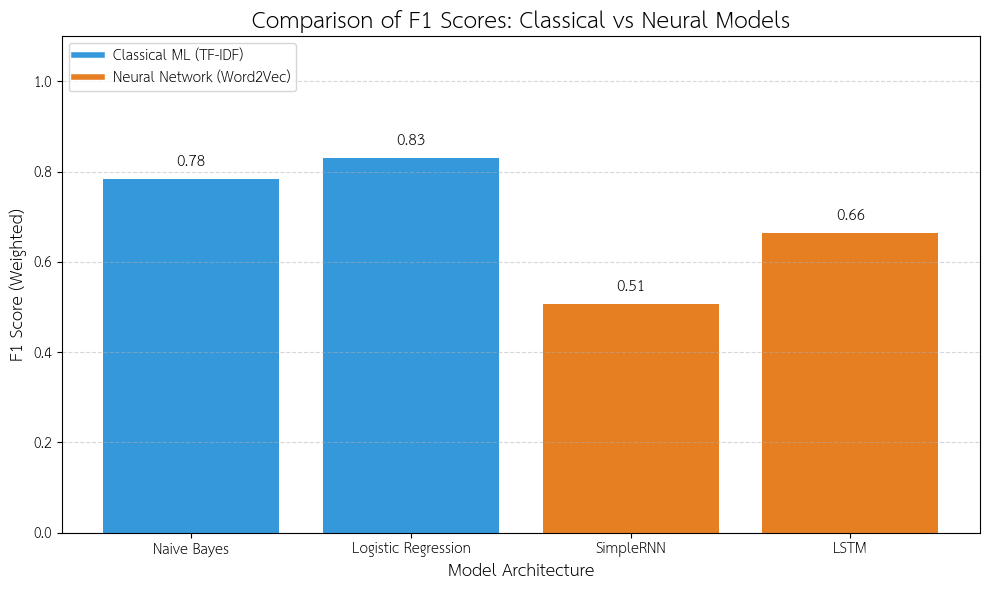

In [ ]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Evaluate Naive Bayes model
f1_nb = f1_score(y_test_enc, le.transform(y_pred_nb), average='weighted')

# Evaluate Logistic Regression model
f1_lr = f1_score(y_test_enc, le.transform(y_pred_lr), average='weighted')

# Evaluate RNN model
y_pred_rnn_probs = rnn_model.predict(X_test_pad)
y_pred_rnn = np.argmax(y_pred_rnn_probs, axis=1)
f1_rnn = f1_score(y_test_enc, y_pred_rnn, average='weighted')

# Evaluate LSTM model
y_pred_lstm_probs = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=1)
f1_lstm = f1_score(y_test_enc, y_pred_lstm, average='weighted')

models = ['Naive Bayes', 'Logistic Regression', 'SimpleRNN', 'LSTM']
f1_scores = [f1_nb, f1_lr, f1_rnn, f1_lstm]
colors = ['#3498db', '#3498db', '#e67e22', '#e67e22']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, f1_scores, color=colors)

plt.xlabel('Model Architecture', fontsize=12)
plt.ylabel('F1 Score (Weighted)', fontsize=12)
plt.title('Comparison of F1 Scores: Classical vs Neural Models', fontsize=16, fontweight='bold')
plt.ylim(0, 1.1) # เผื่อพื้นที่ด้านบนสำหรับแสดงตัวเลข

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# เพิ่มคำอธิบายกลุ่ม (Legend)
legend_elements = [
    Line2D([0], [0], color='#3498db', lw=4, label='Classical ML (TF-IDF)'),
    Line2D([0], [0], color='#e67e22', lw=4, label='Neural Network (Word2Vec)')
]
plt.legend(handles=legend_elements, loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

